In [12]:
import xarray as xr
import numpy as np
import os, sys

In [13]:
os.listdir('/gws/nopw/j04')

['wcssp_india',
 'vision',
 'odanceo',
 'acacia',
 'quasar',
 'tids',
 'scenario',
 'mohc_shared',
 'parachute',
 'ramip']

In [14]:
ROOT_DIR = '/gws/ssde/j25a/extant/data'

In [15]:
potential_models = np.array(os.listdir(ROOT_DIR))
models = np.array([m for m in potential_models if os.path.isdir(os.path.join(ROOT_DIR, m))])
models

array(['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'BCC-ESM1', 'CESM2',
       'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM2', 'CanESM5',
       'E3SM-1-0', 'EC-Earth3-Veg', 'EC-Earth3', 'ERA5', 'FGOALS-g3',
       'GISS-E2-1-G', 'HadGEM3-GC31-CANARI', 'HadGEM3-GC31-LL',
       'HadGEM3-GC31-MM', 'INM-CM5-0', 'IPSL-CM6A-LR', 'MIROC-ES2L',
       'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3',
       'NorESM2-LM', 'RCM', 'UKESM1-0-LL', 'downloading'], dtype='<U19')

In [16]:
LESMIP_MODELS = ['ACCESS-ESM1-5',
       'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CanESM5',
       'GISS-E2-1-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR',
       'MIROC6', 'MPI-ESM1-2-LR',
       'NorESM2-LM']

In [17]:
len(LESMIP_MODELS)

10

In [18]:
from glob import glob

In [19]:
from collections import defaultdict
from pprint import pprint

In [20]:
# nested = lambda: defaultdict(nested)
# model_list_dict = nested()
# model_list_dict

In [21]:
model_list_dict = defaultdict(dict)


for model in LESMIP_MODELS:
    print(model)
    model_path = os.path.join(ROOT_DIR, model, 'day')
    variables = os.listdir(model_path)
    for variable in variables:
        # print(variable)
        variable_path = os.path.join(model_path, variable)
        if os.path.isdir(variable_path): 
            glob_path = os.path.join(variable_path, '**', '*.nc')
            print(f'searching {glob_path}')
            full_paths = glob(glob_path, recursive=True)
            fnames = full_paths#list(map(os.path.basename, full_paths))
            fnames_grouped = defaultdict(list)
            for fname in fnames:
                fnames_grouped[fname.split('_')[3]].append(fname)

            model_list_dict[model][variable] = {'path': variable_path, 'fnames': fnames_grouped}

ACCESS-ESM1-5
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/pr/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/psl/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tas/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tasmax/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/va/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/vas/**/*.nc
CMCC-CM2-SR5
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/pr/**/*.nc
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/tas/**/*.nc
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/tasmax/**/*.nc
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/va/**/*.nc
CNRM-CM6-1
searching /gws/ssde/j25a/extant/data/CNRM-CM6-1/day/psl/**/*.nc
searching /gws/ssde/j25a/extant/data/CNRM-CM6-1/day/tas/**/*.nc
searching /gws/ssde/j25a/extant/data/CNRM-CM6-1/day/tasmax/**/*.nc
searching /gws/ssde/j25a/extant/

In [22]:
model_list_dict

defaultdict(dict,
            {'ACCESS-ESM1-5': {'pr': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/pr',
               'fnames': defaultdict(list, {})},
              'psl': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/psl',
               'fnames': defaultdict(list, {})},
              'tas': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tas',
               'fnames': defaultdict(list, {})},
              'tasmax': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tasmax',
               'fnames': defaultdict(list, {})},
              'uas': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas',
               'fnames': defaultdict(list,
                           {'historical': ['/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas/uas_day_ACCESS-ESM1-5_historical_r10i1p1f1_gn_19500101-19991231.nc',
                             '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas/uas_day_ACCESS-ESM1-5_historical_r10i1p1f1_gn_20000101-20141231.nc',
  

In [23]:
{model: values.get('tasmax') for model, values in model_list_dict.items()}

{'ACCESS-ESM1-5': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tasmax',
  'fnames': defaultdict(list, {})},
 'CMCC-CM2-SR5': {'path': '/gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/tasmax',
  'fnames': defaultdict(list, {})},
 'CNRM-CM6-1': {'path': '/gws/ssde/j25a/extant/data/CNRM-CM6-1/day/tasmax',
  'fnames': defaultdict(list, {})},
 'CanESM5': {'path': '/gws/ssde/j25a/extant/data/CanESM5/day/tasmax',
  'fnames': defaultdict(list, {})},
 'GISS-E2-1-G': {'path': '/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax',
  'fnames': defaultdict(list,
              {'hist-sol': ['/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax/tasmax_day_GISS-E2-1-G_hist-sol_r6i1p1f2_gn_18500101-18991231.nc',
                '/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax/tasmax_day_GISS-E2-1-G_hist-sol_r6i1p1f2_gn_19000101-19391231.nc',
                '/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax/tasmax_day_GISS-E2-1-G_hist-sol_r6i1p1f2_gn_19400101-19791231.nc',
                '/gws/ssde

In [24]:
model = 'HadGEM3-GC31-LL'

In [25]:
sample_dict = model_list_dict[model]['tasmax']

In [26]:
sample_dict.keys()

dict_keys(['path', 'fnames'])

In [27]:
sample_dict['fnames'].keys()

dict_keys(['hist-GHG', 'hist-aer', 'hist-lu', 'hist-nat', 'hist-sol', 'hist-totalO3', 'hist-volc', 'historical', 'day'])

In [28]:
hist_path = sample_dict['fnames']['historical'][0]
hist_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_18500101-19491230.nc'

In [51]:
hist_path_split = os.path.basename(hist_path).split('.')[0].split('_')
experiment, ensemble_member, _, time = hist_path_split[-4:]
experiment, ensemble_member, _, time

('historical', 'r11i1p1f3', 'gn', '18500101-19491230')

In [53]:
hist_match = [f for f in sample_dict['fnames']['historical'] if ((experiment in f) and (ensemble_member in f))]
hist_match

['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_18500101-19491230.nc',
 '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_19500101-20141230.nc']

In [55]:
import re

In [58]:
hist_wild_path = re.sub(r'_gn_\d+-\d+\.nc$', '_gn_*.nc', hist_match[0])
hist_wild_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_*.nc'

In [70]:
hist_da = xr.open_mfdataset(hist_wild_path)

In [60]:
ensmemble_date_str = "_".join(hist_path.split('.')[0].split('_')[-3:])
ensmemble_date_str

'r11i1p1f3_gn_18500101-19491230'

In [61]:
hist_nat_path = sample_dict['fnames']['hist-nat'][0]
hist_nat_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/hist-nat/tasmax_day_HadGEM3-GC31-LL_hist-nat_r10i1p1f3_gn_18500101-19491230.nc'

In [64]:
hist_nat_wild_path = re.sub(r'_gn_\d+-\d+.nc$', '_gn_*.nc',hist_nat_path)
hist_nat_wild_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/hist-nat/tasmax_day_HadGEM3-GC31-LL_hist-nat_r10i1p1f3_gn_*.nc'

In [68]:
hist_nat_da = xr.open_mfdataset(hist_nat_path)
hist_nat_da

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 36000, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) object 288kB 1850-01-01 12:00:00 ... 1949-12-30 12:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 576kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    tasmax     (time, lat, lon) float32 4GB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            DAMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  154800.0
    creation_date:          2021-12-21T14:13:06Z
    ...                     ...
    tracking_id:            hdl:21.14100/3e826075-70b4-4f00-a72f-e79b63e042a0
    variable_id:            tasmax
    variable_name:          tasmax
    variant_label:          r10i1p1f3
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.6.1

In [31]:
#hist_da = xr.open_dataset(hist_path)

In [71]:
import matplotlib.pyplot as plt

In [72]:
arr = hist_da.tasmax.sel(lat=-39, lon=145, method='nearest').values

Text(0.5, 1.0, 'Temperature')

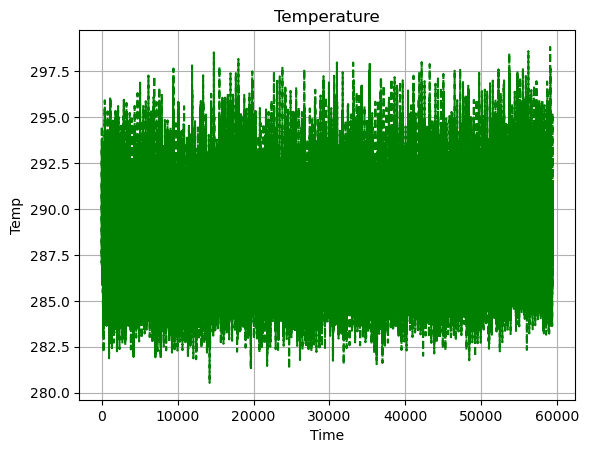

In [73]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(arr, linestyle='--', color='green')
ax.set_ylabel('Temp')
ax.set_xlabel('Time')
ax.grid()
ax.set_title('Temperature')